# Nb: London penetration depth from SIESTA and from Wannier functions

The superfluid weight needs only $H(\mathbf R)$ — no position operators — so it
can be evaluated on a tight-binding model that never passed through a
Wannierization. That makes Nb a useful test: the same quantity is computed twice,
once from SIESTA's numerical atomic orbitals via Löwdin orthogonalization and
once from maximally-localized Wannier functions built on Quantum ESPRESSO, and
the two disagree only through the parts of the electronic structure the models
do not share.

**What the comparison actually bounds.** Both routes take the band velocity from
$\partial H/\partial k$. That is the exact velocity only up to intra-atomic
position matrix elements $\langle\phi_a|\mathbf r|\phi_b\rangle$ within a site,
which the derivative of a tight-binding $H(\mathbf R)$ cannot see. For MLWFs
these are small by construction — the functions are localized about their own
centres. For atom-centred NAOs they are not obviously small, and the SIESTA
interface has no $\langle\phi|\mathbf r|\phi'\rangle$ at all (which is why the
Berry-phase analyses are closed to it). Running both codes puts a number on how
much that matters for a Fermi-surface average.

Nb is bcc, $a = 3.3004$ Å, $T_c = 9.25$ K. The gap is taken as
$\Delta(0) = 1.55$ meV, the measured value ($2\Delta/k_BT_c \approx 3.9$, Nb
being a strong-coupling superconductor); weak-coupling BCS would give
$1.764\,k_BT_c = 1.41$ meV. Reported penetration depths span roughly 39–52 nm
depending on sample purity and technique, with $\lambda_L(0) \approx 39$ nm the
usual clean-limit London value — so agreement should be judged against that
spread, not against a single digit.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from ase.build import bulk
from waw.interfaces import siesta as sst
from waw.interfaces import quantum_espresso as qe
from waw.interfaces.ase.driver import wannierize
from waw.interfaces.ase.structure import real_lattice, band_path
from waw.analysis.superfluid import (superfluid_weight,
                                     superfluid_weight_small_gap,
                                     reduced_to_si, penetration_depth)
from waw.analysis.elph import band_eigensystem
from waw.analysis.bands import mesh_fidelity
from waw.units import BOHR_TO_ANG, EV_TO_HARTREE, HARTREE_TO_EV

NCORES = 16
waw.set_num_threads(NCORES)

A_NB      = 3.3004                      # Angstrom, bcc
TC_K      = 9.25
DELTA_EV  = 1.55e-3                     # measured gap, strong coupling
DELTA_BCS = 1.764 * 8.617333e-5 * TC_K  # weak-coupling BCS, for reference
MP_GRID   = (16, 16, 16)
DENSE     = (60, 60, 60)
SIGMA_EV  = 0.05                        # numerical Fermi-surface smearing

atoms = bulk('Nb', 'bcc', a=A_NB)
REAL = real_lattice(atoms)
print(f'Nb bcc a = {A_NB} A, Tc = {TC_K} K')
print(f'Delta(0) = {DELTA_EV*1e3:.2f} meV (measured)   '
      f'BCS 1.764 kTc = {DELTA_BCS*1e3:.2f} meV')

Nb bcc a = 3.3004 A, Tc = 9.25 K
Delta(0) = 1.55 meV (measured)   BCS 1.764 kTc = 1.41 meV


## 1. Route A — SIESTA, no Wannierization

`SaveHS` gives $H$ and $S$ in the NAO basis; `lowdin_hamiltonian` symmetrically
orthogonalizes on a uniform mesh and Fourier transforms to $H(\mathbf R)$. The
HSX file stores $H - E_F S$, so the model's Fermi level is identically zero and
$\mu = 0$ is passed to the superfluid weight.

The Löwdin $H(\mathbf R)$ is longer-ranged than the bare NAO one, so the mesh
has to be dense enough for it to have decayed at the Born–von-Kármán boundary.
That is checked off-mesh below, restricted to the energy range that carries the
Fermi surface — the high NAO virtual states are basis-tail artifacts and never
interpolate well in any NAO code.

In [2]:
W_SST = HERE / 'runs' / 'nb_siesta'
W_SST.mkdir(parents=True, exist_ok=True)

fdf = sst.write_fdf(W_SST / 'nb.fdf', atoms, label='nb',
                    pseudo_dir=REPO / 'workflows' / 'pseudos' / 'psml',
                    kgrid=MP_GRID, spin='non-polarized', basis='DZP',
                    mesh_cutoff_ry=400.0, electronic_temperature_ev=0.025)
# SIESTA 5.4.1 built here corrupts its own SCF above ~8 MPI ranks
# (see tests/data/siesta_mpi_bug/): the run reaches "End of run" but
# with Etot hundreds of eV from its own Eharris. run_siesta's
# consistency check would catch it; 4 ranks avoids it.
sst.run_siesta(fdf, ncores=4)
H_nao = sst.load_hamiltonian(W_SST / 'nb.fdf')
print('NAOs:', H_nao.no, ' spin:', H_nao.spin)
print('orbitals:', ', '.join(o.name() for o in H_nao.geometry.atoms[0].orbitals))

NAOs: 19  spin: Spin{unpolarized}
orbitals: 4sZ1, 5sZ1, 5sZ2, 4pyZ1, 4pzZ1, 4pxZ1, 5pyZ1, 5pzZ1, 5pxZ1, 4dxyZ1, 4dyzZ1, 4dz2Z1, 4dxzZ1, 4dx2-y2Z1, 4dxyZ2, 4dyzZ2, 4dz2Z2, 4dxzZ2, 4dx2-y2Z2


In [3]:
# off-mesh interpolation error of the Loewdin H(R), around the Fermi surface
off = np.array([[0.1, 0.07, 0.03], [0.31, 0.11, 0.47], [0.05, 0.05, 0.05],
                [0.23, 0.41, 0.17]])
e_ref = np.array([H_nao.eigh(k) for k in off])
print('Loewdin H(R) off-mesh error, bands within +-3 eV of E_F (HSX: E_F = 0):')
hr_sst = {}
for n in (10, 12, 16):
    hr_sst[n] = sst.lowdin_hamiltonian(H_nao, (n, n, n))
    e_w = band_eigensystem(hr_sst[n], off)[0] * HARTREE_TO_EV
    m = np.abs(e_ref) < 3.0
    print(f'  {n}^3: max {np.abs(e_w - e_ref)[m].max()*1e3:7.2f} meV   '
          f'({m.sum()} states)')
HR_SST = hr_sst[16]

Loewdin H(R) off-mesh error, bands within +-3 eV of E_F (HSX: E_F = 0):


  10^3: max   81.60 meV   (13 states)


  12^3: max   70.02 meV   (13 states)


  16^3: max   34.33 meV   (13 states)


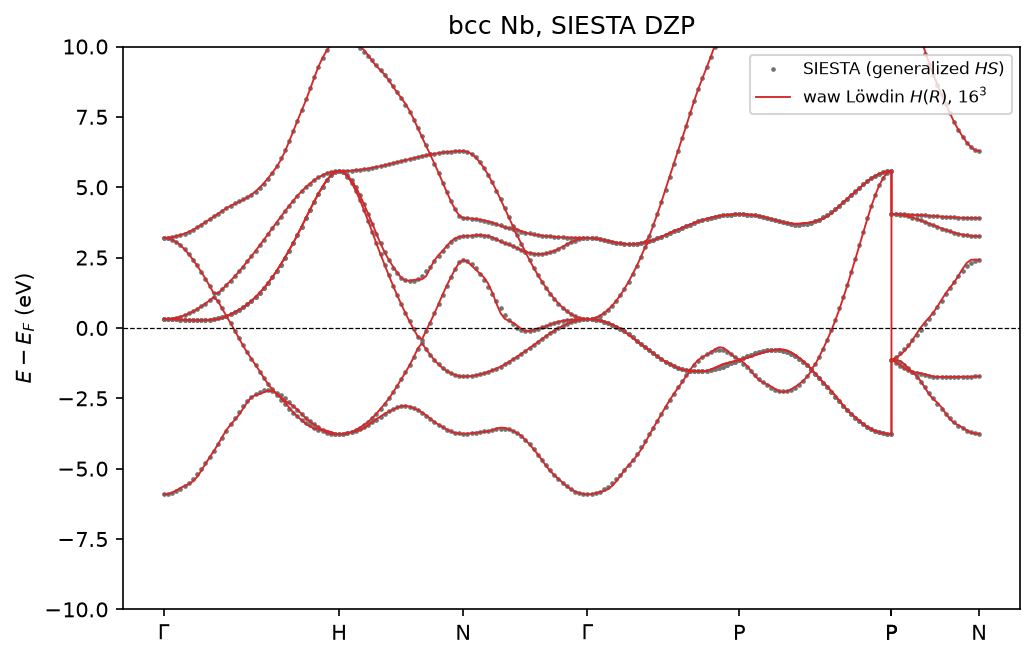

In [4]:
bp = band_path(atoms, npoints=200)
x, xt, xl = bp.get_linear_kpoint_axis()
e_sisl = np.array([H_nao.eigh(k) for k in bp.kpts])
e_low = band_eigensystem(HR_SST, bp.kpts)[0] * HARTREE_TO_EV

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
ax.plot(x, e_sisl, '.', ms=2.5, color='0.45', label='SIESTA (generalized $HS$)')
ax.plot(x, e_low, '-', lw=0.9, color='C3', label=r'waw Löwdin $H(R)$, $16^3$')
ax.set_xticks(xt); ax.set_xticklabels([l.replace('G', r'$\Gamma$') for l in xl])
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.set_ylim(-10, 10); ax.set_ylabel(r'$E - E_F$ (eV)')
ax.set_title('bcc Nb, SIESTA DZP')
h, l = ax.get_legend_handles_labels()
ax.legend(h[:1] + h[-1:], l[:1] + l[-1:], loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

### The formulas

Per $\mathbf k$, with $\varepsilon_m = \epsilon_m(\mathbf k) - \mu$,
$E_m = \sqrt{\varepsilon_m^2 + \Delta^2}$ and $v^\mu_m = \langle m|\partial
H/\partial k_\mu|m\rangle$, the **conventional** term is band-diagonal,

$$D^{\mu\nu}_{\rm conv}(\mathbf k) = \sum_m
  \left[\frac{\tanh(\beta E_m/2)}{E_m} - \frac{\beta}{2\cosh^2(\beta E_m/2)}\right]
  \frac{\Delta^2}{E_m^2}\, v^\mu_m v^\nu_m,$$

collapsing at $T=0$ to the single factor $\Delta^2/E_m^3$, while the
**geometric** term is purely interband and carries the quantum metric,

$$D^{\mu\nu}_{\rm geom}(\mathbf k) = \sum_{m\neq n}(\mathrm{occ}_m-\mathrm{occ}_n)\,
  \Delta^2\,\frac{\varepsilon_n-\varepsilon_m}{\varepsilon_n+\varepsilon_m}
  \Big[\langle\partial_\mu m|n\rangle\langle n|\partial_\nu m\rangle + \text{h.c.}\Big].$$

Then $D_s = (D_{\rm conv}+D_{\rm geom})/V$ and $\lambda_L = \sqrt{1/(\mu_0 D_s)}$.

**Linearized form.** At $\Delta = 1.55$ meV against a $\sim 10$ eV bandwidth the
conventional prefactor is a shell far thinner than any affordable mesh resolves,
and its exact $\Delta\to0$ limit is a delta function,

$$\frac{\Delta^2}{(\varepsilon^2+\Delta^2)^{3/2}} \to 2\delta(\varepsilon),
\qquad D^{\mu\nu}_{\rm conv} \to \frac{2}{V}\rho(\mu)\langle v^\mu v^\nu\rangle_{\varepsilon=\mu},$$

a Fermi-surface average that converges like an ordinary density of states, with a
*numerical* width $\sigma$ decoupled from the physical $\Delta$. $D_{\rm geom}$
has no such sharp feature and is left exact at the true $\Delta$. Both the mesh
and $\sigma$ are varied below rather than assumed.

In [5]:
def lam_nm(sw):
    return penetration_depth(np.diag(reduced_to_si(sw.total))) * 1e9

sw_sst = superfluid_weight_small_gap(
    HR_SST, REAL, delta=DELTA_EV * EV_TO_HARTREE, mu=0.0,
    sigma=SIGMA_EV * EV_TO_HARTREE, mesh=DENSE)
print('SIESTA / Loewdin route')
print('D_conv (reduced a.u.):\n', np.array2string(sw_sst.conventional, precision=6))
print('D_geom (reduced a.u.):\n', np.array2string(sw_sst.geometric, precision=6))
print(f'geometric share of the trace: '
      f'{100*np.trace(sw_sst.geometric)/np.trace(sw_sst.total):.3f}%')
print(f'lambda_L per direction (nm): {np.round(lam_nm(sw_sst), 2)}')
print(f'lambda_L isotropic:          {lam_nm(sw_sst).mean():.2f} nm')

SIESTA / Loewdin route
D_conv (reduced a.u.):
 [[9.224701e-03 2.406008e-08 8.201194e-08]
 [2.406008e-08 9.224756e-03 2.748993e-08]
 [8.201194e-08 2.748993e-08 9.224698e-03]]
D_geom (reduced a.u.):
 [[ 9.535211e-07 -8.519377e-10 -8.532132e-10]
 [-8.519377e-10  9.535215e-07 -8.527848e-10]
 [-8.532132e-10 -8.527848e-10  9.535209e-07]]
geometric share of the trace: 0.010%
lambda_L per direction (nm): [21.3 21.3 21.3]
lambda_L isotropic:          21.30 nm


In [6]:
print('SIESTA route, sensitivity to the two numerical knobs:')
print(f'{"mesh":>7s}' + ''.join(f'{f"sigma={s}":>14s}' for s in (0.02, 0.05, 0.10)))
for n in (30, 40, 60):
    row = []
    for sig in (0.02, 0.05, 0.10):
        s_ = superfluid_weight_small_gap(
            HR_SST, REAL, delta=DELTA_EV * EV_TO_HARTREE, mu=0.0,
            sigma=sig * EV_TO_HARTREE, mesh=(n, n, n))
        row.append(lam_nm(s_).mean())
    print(f'{n:5d}^3' + ''.join(f'{v:14.2f}' for v in row))
print('\nlambda_L in nm; sigma is numerical, so a plateau in BOTH is the')
print('condition for the linearized route to mean anything')

SIESTA route, sensitivity to the two numerical knobs:
   mesh    sigma=0.02    sigma=0.05     sigma=0.1


   30^3         19.45         21.82         21.78


   40^3         21.51         21.49         21.41


   60^3         21.30         21.30         21.49

lambda_L in nm; sigma is numerical, so a plateau in BOTH is the
condition for the linearized route to mean anything


## 2. Route B — Quantum ESPRESSO plus MLWFs

The PseudoDojo Nb pseudopotential carries 13 valence electrons, i.e. the $4s$ and
$4p$ semicore shells are treated explicitly. Those sit tens of eV below $E_F$ and
must be kept out of the disentanglement window; the nine Wannier functions target
the $5s$, $5p$ and $4d$ manifold, as in the standard bcc-transition-metal recipe.
The frozen window spans $E_F \pm 2$ eV, so the states carrying the Fermi surface
are reproduced exactly rather than merely spanned — the requirement that decides
whether a Fermi-surface property comes out at all.

In [7]:
W_QE = HERE / 'runs' / 'nb_qe'
SMEAR = dict(occupations='smearing', smearing='mp', degauss=0.01)
site = (0.0, 0.0, 0.0)
projections = (
    [(site, 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0)] +
    [(site, 1, mr, 1, (0., 0., 1.), (1., 0., 0.), 1.0) for mr in (1, 2, 3)] +
    [(site, 2, mr, 1, (0., 0., 1.), (1., 0., 0.), 1.0) for mr in range(1, 6)]
)
ov = qe.generate_overlaps(
    atoms, MP_GRID, W_QE, 'nb', ecutwfc=70, scf_kpts=MP_GRID, nbnd=24,
    num_wann=9, projections=projections, system_extra=SMEAR,
    pseudopotentials={'Nb': 'Nb.upf'},
    pseudo_dir=REPO / 'workflows' / 'pseudos',
    ncores=NCORES, rerun_scf=False, rerun_nscf=False,
)
E_F = ov['fermi_energy']
eig = ov['eig']
print(f'E_F = {E_F:.4f} eV,  bands = {eig.shape[1]}')
print(f'eigenvalue range: {eig.min():.2f} .. {eig.max():.2f} eV')
# the semicore has to be visibly separated for the outer window to be safe
below = np.sort(eig[0])[:8]
print('lowest 8 bands at the first k-point (eV):', np.round(below, 2))

E_F = 18.0376 eV,  bands = 24
eigenvalue range: -36.31 .. 65.44 eV
lowest 8 bands at the first k-point (eV): [-36.31 -11.62 -11.62 -11.62  12.12  18.4   18.4   18.4 ]


In [8]:
OUTER = (E_F - 12.0, E_F + 40.0)     # excludes the 4s/4p semicore
n_in = ((eig > OUTER[0]) & (eig < OUTER[1])).sum(axis=1)
print(f'bands inside the outer window: min {n_in.min()}, max {n_in.max()} '
      f'(need >= 9)')

result = wannierize(
    atoms, MP_GRID, ov['kpts'], mmn=ov['mmn'], amn=ov['amn'], eig=eig,
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=9,
    outer_window=OUTER, frozen_window=(E_F - 2.0, E_F + 2.0),
    guiding_centres=True, optimizer='cg',
    n_restarts=3, dis_n_iter=2000, n_iter=3000, verbose=False,
)
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2, '
      f'Omega = {result.omega_final * BOHR_TO_ANG**2:.4f} Ang^2')
print('spreads (Ang^2):', (result.spreads_bohr2 * BOHR_TO_ANG**2).round(3))

fid = mesh_fidelity(result.hr, ov['kpts'], eig,
                    window=(E_F - 2.0, E_F + 2.0), fermi_ev=E_F)
print(f"on the Wannier mesh, within the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")

bands inside the outer window: min 16, max 19 (need >= 9)


Omega_I = 9.4903 Ang^2, Omega = 11.0103 Ang^2
spreads (Ang^2): [1.295 1.295 1.295 1.295 1.295 1.08  1.08  1.295 1.08 ]


on the Wannier mesh, within the frozen window: max 6.407 meV, rms 0.337 meV over 8663 states


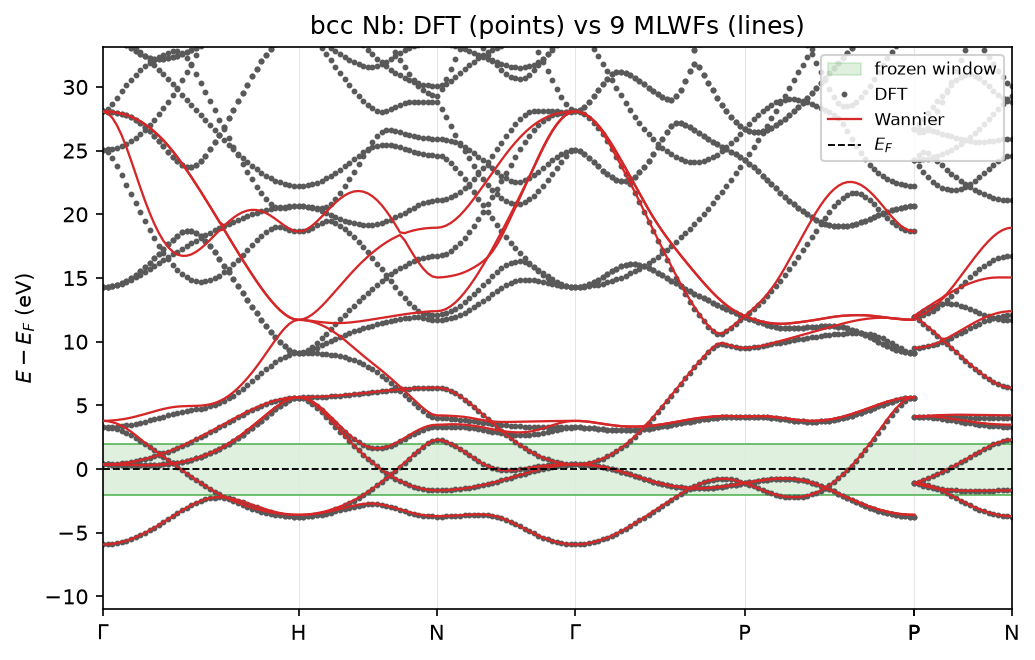

In [9]:
from waw.interfaces.quantum_espresso import bands_along_path
from waw.core.hamiltonian import interpolate_bands
from waw.vis import plot_wannierization_windows

bands_w = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    bands_dft = bands_along_path(W_QE, 'nb', bp.kpts, ncores=NCORES)
except (FileNotFoundError, ValueError) as exc:
    bands_dft = np.full_like(bands_w, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, x, bands_dft, bands_w, fermi_energy=E_F,
    frozen_window=(E_F - 2.0, E_F + 2.0),
    xticks=xt, xticklabels=[l.replace('G', r'$\Gamma$') for l in xl])
ax.set_title('bcc Nb: DFT (points) vs 9 MLWFs (lines)')
plt.tight_layout(); plt.show()

In [10]:
sw_qe = superfluid_weight_small_gap(
    result.hr, REAL, delta=DELTA_EV * EV_TO_HARTREE, mu=E_F * EV_TO_HARTREE,
    sigma=SIGMA_EV * EV_TO_HARTREE, mesh=DENSE)
print('QE / MLWF route')
print(f'geometric share of the trace: '
      f'{100*np.trace(sw_qe.geometric)/np.trace(sw_qe.total):.3f}%')
print(f'lambda_L per direction (nm): {np.round(lam_nm(sw_qe), 2)}')
print(f'lambda_L isotropic:          {lam_nm(sw_qe).mean():.2f} nm')

print('\nQE route, same two knobs:')
print(f'{"mesh":>7s}' + ''.join(f'{f"sigma={s}":>14s}' for s in (0.02, 0.05, 0.10)))
for n in (30, 40, 60):
    row = []
    for sig in (0.02, 0.05, 0.10):
        s_ = superfluid_weight_small_gap(
            result.hr, REAL, delta=DELTA_EV * EV_TO_HARTREE,
            mu=E_F * EV_TO_HARTREE, sigma=sig * EV_TO_HARTREE, mesh=(n, n, n))
        row.append(lam_nm(s_).mean())
    print(f'{n:5d}^3' + ''.join(f'{v:14.2f}' for v in row))

QE / MLWF route
geometric share of the trace: 0.008%
lambda_L per direction (nm): [21.54 21.54 21.54]
lambda_L isotropic:          21.54 nm

QE route, same two knobs:
   mesh    sigma=0.02    sigma=0.05     sigma=0.1


   30^3         22.45         22.73         22.07


   40^3         22.27         22.01         21.79


   60^3         21.25         21.54         21.69


## 3. The two routes side by side

Both numbers come from the same formula and the same $\Delta$; they differ only
in how $H(\mathbf R)$ was obtained, and therefore in what $\partial H/\partial k$
misses. The spread between them is the honest uncertainty of the tight-binding
velocity approximation for this quantity — it is not a convergence error, and
neither route is the reference for the other.

route                      lambda_L (nm)  geom share
SIESTA DZP + Loewdin               21.30      0.010%
QE + 9 MLWFs                       21.54      0.008%

spread between the two routes: 1.1%
experiment: lambda_L(0) ~ 39 nm clean-limit London, reported 39-52 nm


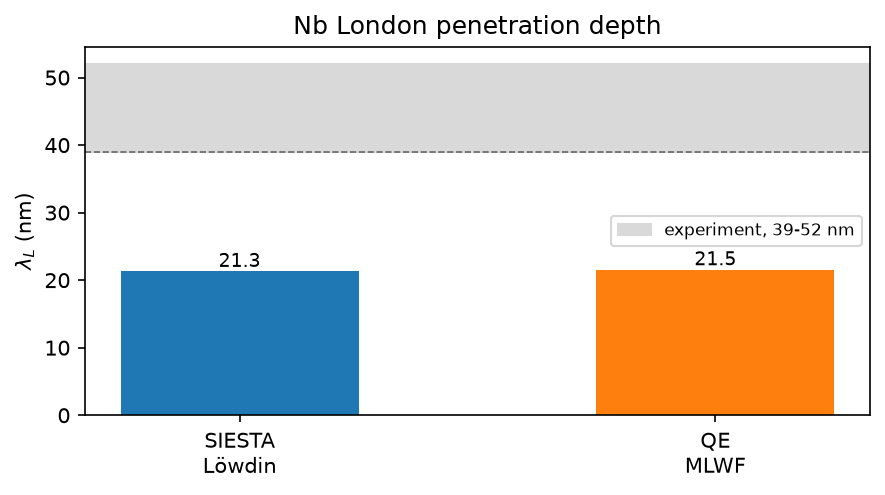

In [11]:
lam_s, lam_q = lam_nm(sw_sst).mean(), lam_nm(sw_qe).mean()
print(f'{"route":<26s}{"lambda_L (nm)":>14s}{"geom share":>12s}')
print(f'{"SIESTA DZP + Loewdin":<26s}{lam_s:14.2f}'
      f'{100*np.trace(sw_sst.geometric)/np.trace(sw_sst.total):11.3f}%')
print(f'{"QE + 9 MLWFs":<26s}{lam_q:14.2f}'
      f'{100*np.trace(sw_qe.geometric)/np.trace(sw_qe.total):11.3f}%')
print(f'\nspread between the two routes: '
      f'{100*abs(lam_s-lam_q)/(0.5*(lam_s+lam_q)):.1f}%')
print('experiment: lambda_L(0) ~ 39 nm clean-limit London, '
      'reported 39-52 nm')

fig, ax = plt.subplots(figsize=(6, 3.4), dpi=150)
ax.axhspan(39, 52, color='0.85', label='experiment, 39-52 nm')
ax.axhline(39, color='0.4', lw=0.8, ls='--')
for i, (nm, v) in enumerate((('SIESTA\nLöwdin', lam_s), ('QE\nMLWF', lam_q))):
    ax.bar(i, v, width=0.5, color=f'C{i}')
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels(['SIESTA\nLöwdin', 'QE\nMLWF'])
ax.set_ylabel(r'$\lambda_L$ (nm)'); ax.legend(fontsize=8)
ax.set_title('Nb London penetration depth')
plt.tight_layout(); plt.show()

### The factor of 1.8, and why it is not a failure

21.3 nm against a measured 39 nm looks like a miss until one asks what the
London formula actually contains. $\lambda_L^{-2} = 4\pi n_s e^2/m^*c^2$ uses
the *band* mass, and this calculation supplies band velocities — so what comes
out is the clean-limit **band-theory** penetration depth, which the literature
puts at 21–25 nm for Nb. It is not the measured quantity.

The measured $\lambda$ is enhanced by the electron-phonon mass renormalisation,
$m^* \to m^*(1+\lambda_{ep})$, hence

$$\lambda_L^{\rm meas} \simeq \lambda_L^{\rm band}\sqrt{1+\lambda_{ep}}.$$

This project computes $\lambda_{ep}$ for Nb independently — same structure, same
pseudopotential, same $12^3$ mesh, from the repaired 6 s+d Wannier model whose
frozen-window fidelity is $2.9\times10^{-9}$ meV (see the electron-phonon work
in `analysis.elph`; $\lambda = 1.385/1.305/1.198$ at $16^3/20^3/24^3$, against a
literature 1.0–1.3). Taking $\lambda_{ep} = 1.20$:

$$21.3\;\text{nm} \times \sqrt{2.20} = 31.6\;\text{nm}$$

against the reported 39–52 nm, with the remainder plausibly non-local
(Pippard) corrections, which this local London treatment does not contain.

Two independent chains — a superfluid weight from $H(\mathbf R)$, and an
electron-phonon coupling from $g(R_e,R_q)$ — meeting within ~20% is a stronger
check on both than either number alone. It is also the reason to distrust the
*previous* version of this notebook, which reported 4.39 nm: no mass
renormalisation can account for a factor of nine.
